<a href="https://colab.research.google.com/github/sadiksha1920/DSA/blob/master/day20_ANN_regression_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving car_purchasing.csv to car_purchasing.csv


{'car_purchasing.csv': b'customer name,JobTitle,customer e-mail,country,gender,age,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,credit card debt,net worth,car purchase amount\r\nMartina Avila,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,42,167411.18,0,400184.25,,567595.43,567595.43,11609.38091,238961.2505,35321.45877\r\nHarlan Barnes,CAPTAIN III (POLICE DEPARTMENT),eu.dolor@diam.co.uk,Belize,0,41,155966.02,245131.88,137811.38,,538909.28,538909.28,9572.957136,530973.9078,45115.52566\r\nNaomi Rodriquez,CAPTAIN III (POLICE DEPARTMENT),vulputate.mauris.sagittis@ametconsectetueradipiscing.co.uk,Algeria,1,43,212739.13,106088.18,16452.6,,335279.91,335279.91,11160.35506,638467.1773,42925.70921\r\nJade Cunningham,WIRE ROPE CABLE MAINTENANCE MECHANIC,malesuada@dignissim.com,Cook Islands,1,58,77916,56120.71,198306.9,,332343.61,332343.61,14426.16485,548599.0524,67422.36313\r\nCedric Leach,"DEPUTY CHIEF OF DEPARTMENT,

In [2]:
import pandas as pd
import numpy as np

#load dataset
df = pd.read_csv('/content/car_purchasing.csv',encoding ='latin1')


In [3]:
df

,customer name,JobTitle,customer e-mail,country,gender,age,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,credit card debt,net worth,car purchase amount
0,Martina Avila,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,42,167411.18,0.00,400184.25,NaN,567595.43,567595.43,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,CAPTAIN III (POLICE DEPARTMENT),eu.dolor@diam.co.uk,Belize,0,41,155966.02,245131.88,137811.38,NaN,538909.28,538909.28,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,CAPTAIN III (POLICE DEPARTMENT),vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43,212739.13,106088.18,16452.60,NaN,335279.91,335279.91,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,WIRE ROPE CABLE MAINTENANCE MECHANIC,malesuada@dignissim.com,Cook Islands,1,58,77916.00,56120.71,198306.90,NaN,332343.61,332343.61,14426.164850,548599.0524,67422.36313
4,Cedric Leach,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57,134401.60,9737.00,182234.59,NaN,326373.19,326373.19,5358.712177,560304.0671,55915.46248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Walter,TRANSIT SUPERVISOR,ligula@Cumsociis.ca,Nepal,0,41,87384.60,97729.16,837.79,NaN,185951.55,185951.55,6995.902524,541670.1016,48901.44342
496,Vanna,"LIEUTENANT, FIRE DEPARTMENT",Cum.sociis.natoque@Sedmolestie.edu,Zimbabwe,1,38,123105.00,38790.92,23865.00,NaN,185760.92,185760.92,12301.456790,360419.0988,31491.41457
497,Pearl,DEPUTY DIRECTOR V,penatibus.et@massanonante.com,Philippines,1,54,185724.50,0.00,0.00,NaN,185724.50,185724.50,10611.606860,764531.3203,64147.28888
498,Nell,MANAGER VIII,Quisque.varius@arcuVivamussit.net,Botswana,1,59,185724.50,0.00,0.00,NaN,185724.50,185724.50,14013.034510,337826.6382,45442.15353


In [5]:
#Drop non informative columns
df = df.drop([
    'customer name',
    'customer e-mail',
    'JobTitle',
    'country'
],axis=1)

#check missing values
print(df.isna().sum())

gender                   0
age                      0
BasePay                  0
OvertimePay              0
OtherPay                 0
Benefits               500
TotalPay                 0
TotalPayBenefits         0
credit card debt         0
net worth                0
car purchase amount      0
dtype: int64


In [6]:
df

,gender,age,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,credit card debt,net worth,car purchase amount
0,0,42,167411.18,0.00,400184.25,NaN,567595.43,567595.43,11609.380910,238961.2505,35321.45877
1,0,41,155966.02,245131.88,137811.38,NaN,538909.28,538909.28,9572.957136,530973.9078,45115.52566
2,1,43,212739.13,106088.18,16452.60,NaN,335279.91,335279.91,11160.355060,638467.1773,42925.70921
3,1,58,77916.00,56120.71,198306.90,NaN,332343.61,332343.61,14426.164850,548599.0524,67422.36313
4,1,57,134401.60,9737.00,182234.59,NaN,326373.19,326373.19,5358.712177,560304.0671,55915.46248
...,...,...,...,...,...,...,...,...,...,...,...
495,0,41,87384.60,97729.16,837.79,NaN,185951.55,185951.55,6995.902524,541670.1016,48901.44342
496,1,38,123105.00,38790.92,23865.00,NaN,185760.92,185760.92,12301.456790,360419.0988,31491.41457
497,1,54,185724.50,0.00,0.00,NaN,185724.50,185724.50,10611.606860,764531.3203,64147.28888
498,1,59,185724.50,0.00,0.00,NaN,185724.50,185724.50,14013.034510,337826.6382,45442.15353


In [7]:
df = df.fillna(0)

In [10]:
X = df.drop('car purchase amount',axis=1)
y = df['car purchase amount']


In [11]:
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
#regression
from tensorflow import keras
from tensorflow.keras import layers

reg_model = keras.Sequential([
    layers.Dense(64, activation ='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  #regression output
])
reg_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']

)

reg_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 2076117760.0000 - mae: 44200.2227 - val_loss: 1938586880.0000 - val_mae: 42924.3516
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2075990272.0000 - mae: 44198.7773 - val_loss: 1938419712.0000 - val_mae: 42922.4492
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2075790592.0000 - mae: 44196.5391 - val_loss: 1938158592.0000 - val_mae: 42919.4766
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2075467392.0000 - mae: 44192.9922 - val_loss: 1937755776.0000 - val_mae: 42914.8984
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2074978048.0000 - mae: 44187.5547 - val_loss: 1937139712.0000 - val_mae: 42907.9219
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2074245760.0000 - mae: 44179.4297 - val_loss: 1936246144.0000 - val_mae: 42897.8320
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2073190400.0000 - mae: 44167.8711 - val_loss: 1935006080.0000 - val_mae: 42883.8438
E

In [15]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

y_pred = reg_model.predict(X_test)

print("MSE:", mean_squared_error(y_test,y_pred))
print("MAE:", mean_absolute_error(y_test,y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
MSE: 1104866629.878757
MAE: 32182.175355374216


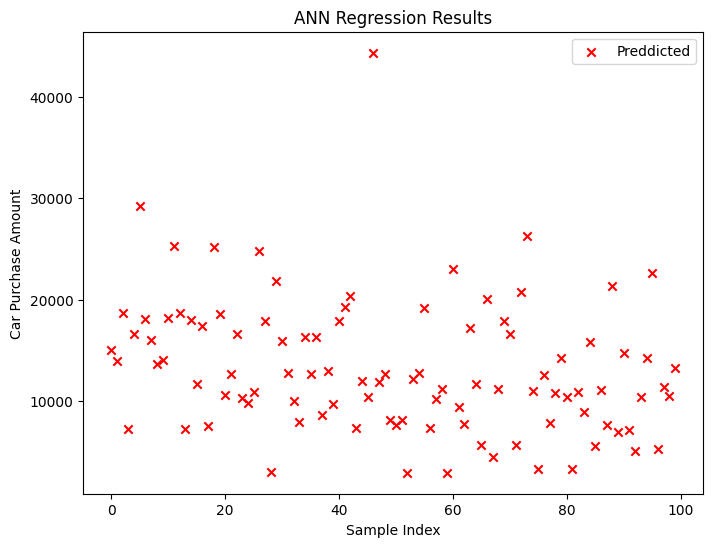

In [21]:
import matplotlib.pyplot as plt
#convert tensor yo numpy if using Tensorflow
y_test_np = y_test.numpy() if hasattr(y_test,"numpy") else y_test
y_pred_np = y_pred.numpy() if hasattr(y_pred,"numpy") else y_pred

#scatter plot with different colors
plt.figure(figsize=(8,6))

#plot actual values(y_test) as red dots
plt.scatter(np.arange(len(y_pred_np)),y_pred_np,color='red',label='Preddicted',marker='x')

plt.xlabel("Sample Index")
plt.ylabel("Car Purchase Amount")
plt.title("ANN Regression Results")
plt.legend()
plt.show()

In [23]:
new_customer = np.array([[
    1,           #gender
    45,         #age
    50000,      #BasePay
    2000,        #OvertimePay
    1500,       #OhterPay
    3000,       #Benefits
    56500,      #TotalPay
    59500,      #TotalPayBenefits
    8000,       #credit card debt
    120000      #networth
]])
#Scale using trained scaler
new_customer_scaled = scaler.transform(new_customer)

#Predict
predicted_amount = reg_model.predict(new_customer_scaled)
print("Predicted Car Purchase Amount:",predicted_amount[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted Car Purchase Amount: 908042.4


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [27]:
y_class = pd.qcut(
    y,
    q=3,
    labels=[0,1,2]
)
#COnvert category ->int
y_calss =y_class.astype(int)


In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report,confusion_matrix

In [32]:
y_cat = to_categorical(y_class,num_classes=3)

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y_cat, test_size=0.2,random_state=42)

In [35]:
model = keras.Sequential([
    layers.Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
    layers.Dense(32,activation='relu'),
    layers.Dense(3,activation='softmax') #3 categorical outputs
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
history = model.fit(
    X_train,
    y_train,
    validation_split =0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3938 - loss: 26379.1562 - val_accuracy: 0.3750 - val_loss: 7246.7451
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3844 - loss: 5280.8896 - val_accuracy: 0.4250 - val_loss: 4149.1646
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4156 - loss: 3233.7908 - val_accuracy: 0.4625 - val_loss: 3013.6030
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4375 - loss: 1985.0100 - val_accuracy: 0.4375 - val_loss: 2143.2603
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4469 - loss: 1321.0133 - val_accuracy: 0.5000 - val_loss: 1721.5153
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4500 - loss: 1109.8278 - val_accuracy: 0.3625 - val_loss: 1690.1409
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4406 - loss: 831.8848 - val_accuracy: 0.4250 - val_loss: 1263.0953
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4688

In [39]:
y_pred = np.argmax(model.predict(X_test),axis=1)
y_true = np.argmax(y_test,axis=1)

print(confusion_matrix(y_true,y_pred))
print(classification_report(y_true,y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[15 11  2]
 [18 13  4]
 [18  7 12]]
              precision    recall  f1-score   support

           0       0.29      0.54      0.38        28
           1       0.42      0.37      0.39        35
           2       0.67      0.32      0.44        37

    accuracy                           0.40       100
   macro avg       0.46      0.41      0.40       100
weighted avg       0.48      0.40      0.41       100

